# 06_analisis_exploratorio

Proyecto ARIMA / ARIMAX
Modelación epidemiológica con variables meteorológicas.

# Inicio del análisis


Para esta **etapa de análisis exploratorio (EDA)** en el estudio del comportamiento del dengue en Caucasia con relación a variables meteorológicas, seguiremos una estructura de un **mini–diagnóstico epidemiológico y climático de la serie temporal**. 




# 1. Verificación estructural de la base

Primero asegúrate de que la serie es consistente.

Objetivos:

* Semanas consecutivas
* Sin duplicados
* Sin huecos


# Lectura y conversión a dataframe de el dataset fusionado 

In [2]:
import pandas as pd 

path_marco = r"C:\Users\marco\Documentos\investigacion\arima\1_programa_trabajo\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\datos_fusionados_semanales.csv"
df_fusionado = pd.read_csv(path_marco)
# hacer que fecha sea el indice y sea de tiipo datetime
df_fusionado['fecha'] = pd.to_datetime(df_fusionado['fecha'])
df_fusionado.set_index('fecha', inplace=True) 
df_fusionado.head()

,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
fecha,,,,,,,,,,,,,,
2021-01-02,2020,53,0,27.910000,34.175000,23.610000,17.300000,76.100000,15.71,2,0.120000,0.235000,0.030000,2.330000
2021-01-09,2021,1,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
2021-01-16,2021,2,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2021-01-23,2021,3,0,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
2021-01-30,2021,4,1,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143


# Visualización tabular 

In [5]:
df_fusionado.info()


<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha                  210 non-null    str    
 1   año                    210 non-null    int64  
 2   semana_epidemiologica  210 non-null    int64  
 3   casos_dengue           210 non-null    int64  
 4   temp                   210 non-null    float64
 5   temp_max               210 non-null    float64
 6   temp_min               210 non-null    float64
 7   hum_esp                210 non-null    float64
 8   hum_rel                210 non-null    float64
 9   prec                   210 non-null    float64
 10  dias_lluvia            210 non-null    int64  
 11  vel_vi                 210 non-null    float64
 12  vel_vi_max             210 non-null    float64
 13  vel_vi_min             210 non-null    float64
 14  uv                     210 non-null    float64
dtypes: float64(10), i

# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 

In [5]:
df_fusionado.describe().round(1)



,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
count,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0,210.0
mean,2022.5,26.5,26.1,27.6,31.7,24.5,18.5,81.6,29.6,4.1,0.1,0.3,0.0,2.2
std,1.1,15.2,25.6,1.6,3.0,0.9,1.6,11.1,27.7,2.4,0.0,0.1,0.0,0.2
min,2020.0,1.0,0.0,24.9,27.1,21.8,15.0,55.9,0.0,0.0,0.1,0.2,0.0,1.7
25%,2021.2,13.2,6.2,26.4,29.3,23.9,17.2,71.0,8.9,2.0,0.1,0.2,0.0,2.0
50%,2022.5,26.5,18.0,27.1,30.5,24.5,18.7,86.4,22.5,4.0,0.1,0.3,0.0,2.2
75%,2023.8,39.8,38.0,28.8,34.3,25.0,19.9,91.2,41.9,6.0,0.2,0.4,0.0,2.3
max,2025.0,53.0,143.0,32.7,39.0,27.7,21.1,94.1,160.4,7.0,0.2,0.5,0.1,2.7


# Tarea: redactar la interpretación de esta tabla para el trabajo de grado y el artículo 


Verificar continuidad temporal:

```python


In [ ]:
df_fusionado.asfreq("W-SAT") # convertir a frecuencia semanal, con el sábado como día de referencia


,año,semana_epidemiologica,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv
fecha,,,,,,,,,,,,,,
2021-01-02,2020,53,0,27.910000,34.175000,23.610000,17.300000,76.100000,15.71,2,0.120000,0.235000,0.030000,2.330000
2021-01-09,2021,1,1,28.252857,34.200000,23.832857,16.308571,70.508571,5.72,1,0.121429,0.244286,0.047143,2.222857
2021-01-16,2021,2,0,28.687143,34.910000,24.195714,17.318571,72.885714,19.15,5,0.117143,0.208571,0.038571,2.254286
2021-01-23,2021,3,0,29.592857,36.372857,24.090000,16.112857,65.122857,0.77,0,0.124286,0.225714,0.045714,2.420000
2021-01-30,2021,4,1,29.190000,35.978571,24.200000,16.511429,68.068571,12.92,4,0.122857,0.220000,0.035714,2.477143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-07,2024,49,143,26.521429,29.908571,24.115714,19.595714,90.112857,18.76,3,0.157143,0.357143,0.054286,1.762857
2024-12-14,2024,50,116,26.795714,30.527143,23.571429,19.075714,86.485714,7.92,1,0.194286,0.521429,0.021429,1.921429
2024-12-21,2024,51,97,26.630000,29.824286,24.062857,19.545714,89.310000,10.38,3,0.155714,0.425714,0.021429,1.652857



Revisar faltantes:

```python


In [7]:
df_fusionado.isna().sum()


año                      0
semana_epidemiologica    0
casos_dengue             0
temp                     0
temp_max                 0
temp_min                 0
hum_esp                  0
hum_rel                  0
prec                     0
dias_lluvia              0
vel_vi                   0
vel_vi_max               0
vel_vi_min               0
uv                       0
dtype: int64


# 2. Evolución temporal de los casos de dengue

Esto permite ver:

* brotes
* estacionalidad
* tendencias

```python


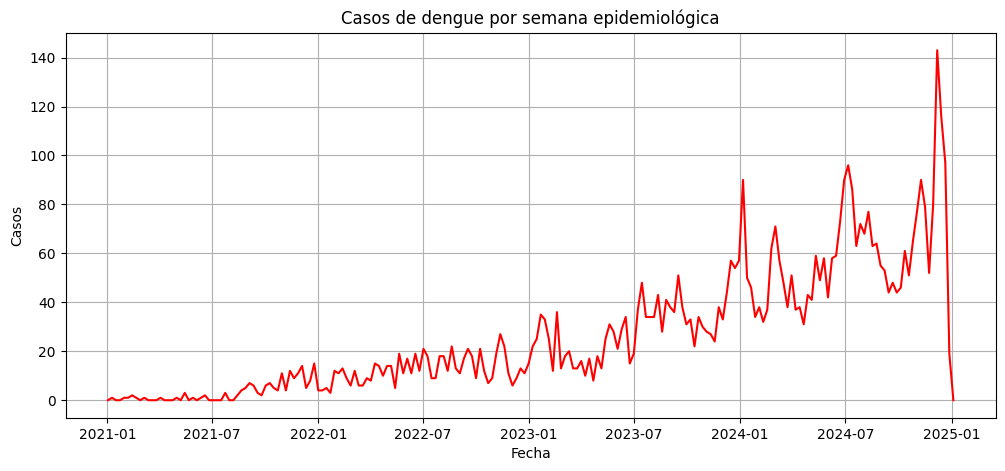

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df_fusionado.index, df_fusionado["casos_dengue"], color="red", marker="", linestyle="-")

plt.title("Casos de dengue por semana epidemiológica")
plt.xlabel("Fecha")
plt.ylabel("Casos")
plt.grid()
plt.show()


Observa:

* picos epidémicos
* ciclos anuales
* cambios estructurales.

---

# 3. Comportamiento de las variables climáticas

```python


In [15]:
df_fusionado.columns 

Index(['año', 'semana_epidemiologica', 'casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv'],
      dtype='str')

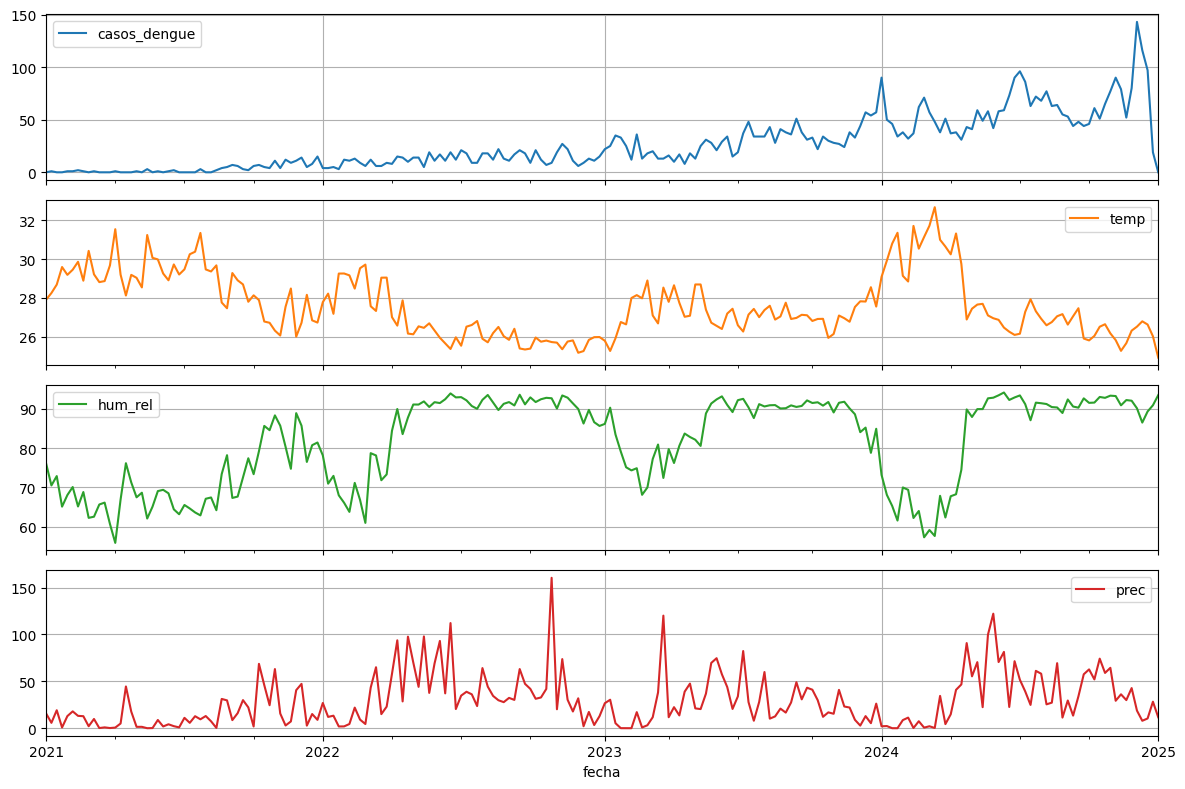

In [18]:
import matplotlib.pyplot as plt

axes = df_fusionado[['casos_dengue', 'temp', 'hum_rel', 'prec']].plot(
    subplots=True,
    figsize=(12, 8)
)

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()


Busca:

* temporadas lluviosas
* ciclos climáticos
* anomalías.

---

# 4. Distribución estadística

Esto ayuda a decidir transformaciones para ARIMA.

```python


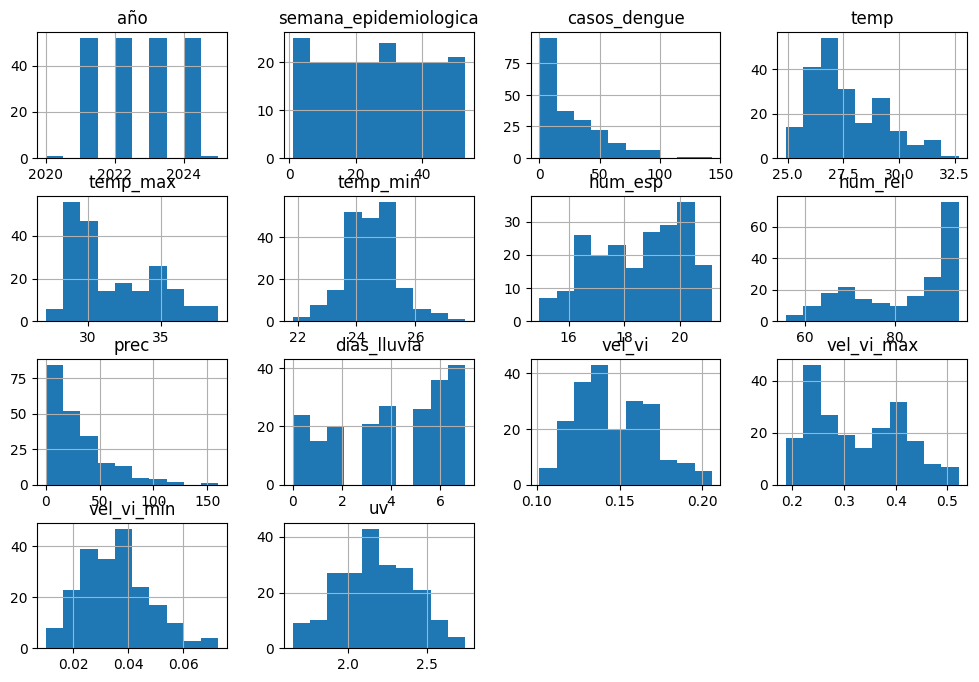

In [21]:
df_fusionado.hist(figsize=(12,8))
plt.savefig("histogramas.png")
plt.show()

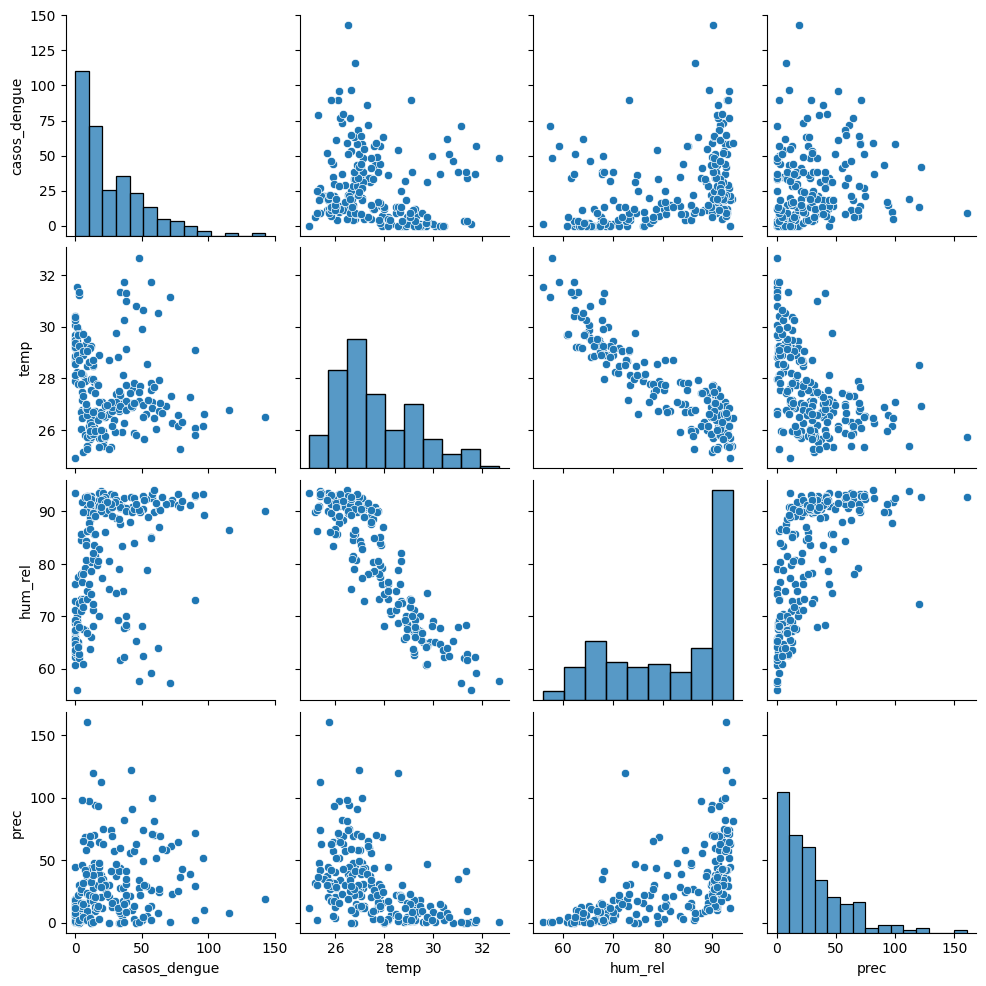

In [23]:
# graficar en una matriz todos los scaterter plots entre las variables numéricas
import seaborn as sns   
sns.pairplot(df_fusionado[['casos_dengue', 'temp', 'hum_rel', 'prec']])
plt.savefig("scatter_matrix.png")
plt.show()


Especial atención a:

* `casos_dengue`
* `prec`

Muchas veces requieren **log-transform**.

---

# 5. Correlación simple

Primer vistazo a relaciones clima–dengue.

```python


<Axes: >

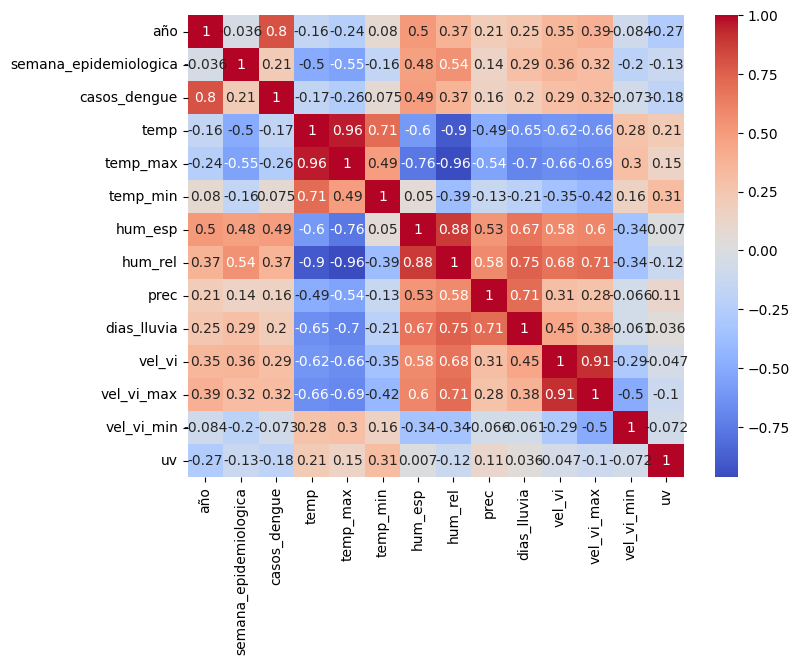

In [26]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df_fusionado.corr(), annot=True, cmap="coolwarm")


```

Observa si:

* lluvia
* humedad
* temperatura

tienen asociación.

---

# 6. Relación visual clima – dengue

Muy útil para docencia.

```python
plt.figure(figsize=(10,5))

plt.scatter(df_epi_meteo["prec"], df_epi_meteo["casos_dengue"])

plt.xlabel("Precipitación")
plt.ylabel("Casos de dengue")

plt.show()
```

---

# 7. Estacionalidad epidemiológica

Muy importante para dengue.

```python
df_epi_meteo.groupby("semana_epidemiologica")["casos_dengue"].mean().plot(figsize=(10,5))
```

Esto muestra:

* semanas de mayor riesgo
* patrón anual.

---

# 8. Análisis de rezagos climáticos (clave para ARIMAX)

El mosquito responde con retraso.

```python
from pandas.plotting import lag_plot

lag_plot(df_epi_meteo["prec"], lag=4)
```

También:

```python
df_epi_meteo["prec"].corr(df_epi_meteo["casos_dengue"].shift(-4))
```

Muchos estudios encuentran retrasos de:

* 2 semanas
* 4 semanas
* 8 semanas.

---

# 9. Descomposición de la serie

Esto ayuda a ver:

* tendencia
* estacionalidad
* ruido.

```python
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df_epi_meteo["casos_dengue"], model="additive", period=52)

decomp.plot()
```

---

# 10. Identificación preliminar para ARIMA

Antes de modelar:

```python
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_epi_meteo["casos_dengue"])
plot_pacf(df_epi_meteo["casos_dengue"])
```

Esto orienta:

* orden AR
* orden MA
* necesidad de diferenciación.

---

# Cómo dejar esta etapa metodológicamente sólida (para un paper)

Puedes estructurar tu notebook así:

```
1_descripcion_datos
2_visualizacion_series
3_estacionalidad
4_relaciones_climaticas
5_lags_climaticos
6_diagnostico_series
```

---

# Algo importante para tu investigación

Muchos artículos fallan porque no revisan **correlación cruzada con rezagos**.

Ese análisis suele revelar cosas como:

```
lluvia  → aumento dengue 3 a 6 semanas después
```

Esto es exactamente lo que necesitas para **ARIMAX epidemiológico**.

---

Si quieres, puedo darte también el **EDA específico que usan los artículos de dengue publicados en revistas Q1**, que mejora mucho la calidad del modelo. 🦟📊
